In [1]:
import time
t1 = time.time()

import math
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
##### load data #####

hhvv_HLdata_path = "/root/data/mucollider/two_boosted/10TeV/scan_kappa3_hhvv_HL.h5"
hhvv_HLdata_file = h5py.File(hhvv_HLdata_path, 'r')
print(hhvv_HLdata_file.keys())

hhmumu_HLdata_path = "/root/data/mucollider/two_boosted/10TeV/scan_kappa3_hhmumu_HL.h5"
hhmumu_HLdata_file = h5py.File(hhmumu_HLdata_path, 'r')
print(hhmumu_HLdata_file.keys())

<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_kappa_3']>
<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_kappa_3']>


In [3]:
##### include data #####

HLfeatures = ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']
# HLfeatures = ['H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'dEta_JJ', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']

##### select BTag work point at WP70 (BitNumber 1) #####

hhvv_BTag_leading = ((hhvv_HLdata_file['BTag_leading'][:])&2)
hhvv_BTag_subleading = ((hhvv_HLdata_file['BTag_subleading'][:])&2)

hhmumu_BTag_leading = ((hhmumu_HLdata_file['BTag_leading'][:])&2)
hhmumu_BTag_subleading = ((hhmumu_HLdata_file['BTag_subleading'][:])&2)

##### include other high level features data #####

hhvv_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': hhvv_HLdata.append(hhvv_BTag_leading)
    elif feature=='BTag_subleading': hhvv_HLdata.append(hhvv_BTag_subleading)
    else: hhvv_HLdata.append(hhvv_HLdata_file[feature][:])
hhvv_HLdata = np.array(hhvv_HLdata).T
print('shape of high level data:', hhvv_HLdata.shape)

hhmumu_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': hhmumu_HLdata.append(hhmumu_BTag_leading)
    elif feature=='BTag_subleading': hhmumu_HLdata.append(hhmumu_BTag_subleading)
    else: hhmumu_HLdata.append(hhmumu_HLdata_file[feature][:])
hhmumu_HLdata = np.array(hhmumu_HLdata).T
print('shape of high level data:', hhmumu_HLdata.shape)

shape of high level data: (251199, 16)
shape of high level data: (265668, 16)


In [4]:
##### define the event information #####

BR_hbb = 0.5824
Luminosity = 1000   ### unit: fb^-1
simulation_num = 100000
kappa3 = [0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8]

hhvv_Xsection_NoDecay = [5.71348e-01, 4.93855e-01, 4.26858e-01, 3.712657e-01, 3.481293e-01, 3.27342e-01, 3.094141e-01, 2.938920e-01, 2.714127e-01, 2.600301e-01, 2.593994e-01]     ### hhvv unit: fb
hhvv_Xsection = [hhvv_Xsection_NoDecay[i]*BR_hbb*BR_hbb for i in range(11)]
hhvv_event_num = []
for kappa3_val in kappa3:
    hhvv_event_num.append(sum(hhvv_HLdata_file['target_kappa_3'][:]==kappa3_val))
print("hhvv event numbers:", hhvv_event_num)

hhmumu_Xsection_NoDecay = [8.0269335e-2, 7.0764282e-2, 6.2857524e-2, 5.5497495e-2, 5.251978e-2, 4.945395e-2, 4.6772324e-2, 4.448303e-2, 4.055381e-2, 3.7546435e-2, 3.556333e-2]     ### hhmumu unit: fb
hhmumu_Xsection = [hhmumu_Xsection_NoDecay[i]*BR_hbb*BR_hbb for i in range(11)]
hhmumu_event_num = []
for kappa3_val in kappa3:
    hhmumu_event_num.append(sum(hhmumu_HLdata_file['target_kappa_3'][:]==kappa3_val))
print("hhmumu event numbers:", hhmumu_event_num)

hhvv event numbers: [26902, 26110, 25064, 24321, 23650, 22742, 22065, 21558, 20382, 19294, 19111]
hhmumu event numbers: [27509, 26827, 26032, 25242, 24700, 24391, 23795, 23234, 22206, 21426, 20306]


In [5]:
##### select the training data #####

hhvv_04data = hhvv_HLdata[sum(hhvv_event_num[0:kappa3.index(0.4)]):sum(hhvv_event_num[0:kappa3.index(0.4)+1])]
hhvv_16data = hhvv_HLdata[sum(hhvv_event_num[0:kappa3.index(1.6)]):sum(hhvv_event_num[0:kappa3.index(1.6)+1])]
print("kappa3 = 0.4, hhvv datashape:", hhvv_04data.shape)
print("kappa3 = 1.6, hhvv datashape:", hhvv_16data.shape)

hhvv_target_04 = np.zeros(hhvv_event_num[kappa3.index(0.4)])
hhvv_target_16 = np.ones(hhvv_event_num[kappa3.index(1.6)])

hhmumu_04data = hhmumu_HLdata[sum(hhmumu_event_num[0:kappa3.index(0.4)]):sum(hhmumu_event_num[0:kappa3.index(0.4)+1])]
hhmumu_16data = hhmumu_HLdata[sum(hhmumu_event_num[0:kappa3.index(1.6)]):sum(hhmumu_event_num[0:kappa3.index(1.6)+1])]
print("kappa3 = 0.4, hhmumu datashape:", hhmumu_04data.shape)
print("kappa3 = 1.6, hhmumu datashape:", hhmumu_16data.shape)

hhmumu_target_04 = np.zeros(hhmumu_event_num[kappa3.index(0.4)])
hhmumu_target_16 = np.ones(hhmumu_event_num[kappa3.index(1.6)])

X = np.concatenate((hhvv_04data, hhmumu_04data, hhvv_16data, hhmumu_16data))
Y = np.concatenate((hhvv_target_04, hhmumu_target_04, hhvv_target_16, hhmumu_target_16))

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=2330, shuffle=True)
print("\nAfter training validation data split:")
print(f"Training features data shape: {X_train.shape}, Validation features data shape: {X_val.shape}")
print(f"Training targets data shape: {Y_train.shape}, Validation targets data shape: {Y_val.shape}")

kappa3 = 0.4, hhvv datashape: (26110, 16)
kappa3 = 1.6, hhvv datashape: (19294, 16)
kappa3 = 0.4, hhmumu datashape: (26827, 16)
kappa3 = 1.6, hhmumu datashape: (21426, 16)

After training validation data split:
Training features data shape: (74925, 16), Validation features data shape: (18732, 16)
Training targets data shape: (74925,), Validation targets data shape: (18732,)


In [6]:
##### train the model #####

xgb_0416 = XGBClassifier(n_estimators=100, learning_rate= 0.1, gamma=6, max_depth=6, objective='binary:logistic', random_state=2330)
xgb_0416.fit(X_train, Y_train)

print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:125.9784(s)


In [7]:
##### test if the model is overfitted #####

Y_pred_tr = xgb_0416.predict(X_train)
tr_accuracy = accuracy_score(Y_train, Y_pred_tr)
print(f"train accuracy: {tr_accuracy * 100:.2f}%")

Y_pred = xgb_0416.predict(X_val)
accuracy = accuracy_score(Y_val, Y_pred)
print(f"test accuracy: {accuracy * 100:.2f}%")

train accuracy: 66.24%
test accuracy: 63.75%


In [8]:
### save the model ###

xgb_0416.save_model("/root/data/mucollider/two_boosted/10TeV/ML_model/xgb_0416_v1.json")

In [9]:
##### model test #####

hhvv_HLtest = []
hhvv_prediction = []

hhmumu_HLtest = []
hhmumu_prediction = []

count = 0
for kappa3_val in kappa3:
    hhvv_HLtest.append(hhvv_HLdata[count:count+hhvv_event_num[kappa3.index(kappa3_val)]])
    hhvv_prediction.append(xgb_0416.predict_proba(hhvv_HLtest[-1]))
    count += hhvv_event_num[kappa3.index(kappa3_val)]

count = 0
for kappa3_val in kappa3:
    hhmumu_HLtest.append(hhmumu_HLdata[count:count+hhmumu_event_num[kappa3.index(kappa3_val)]])
    hhmumu_prediction.append(xgb_0416.predict_proba(hhmumu_HLtest[-1]))
    count += hhmumu_event_num[kappa3.index(kappa3_val)]

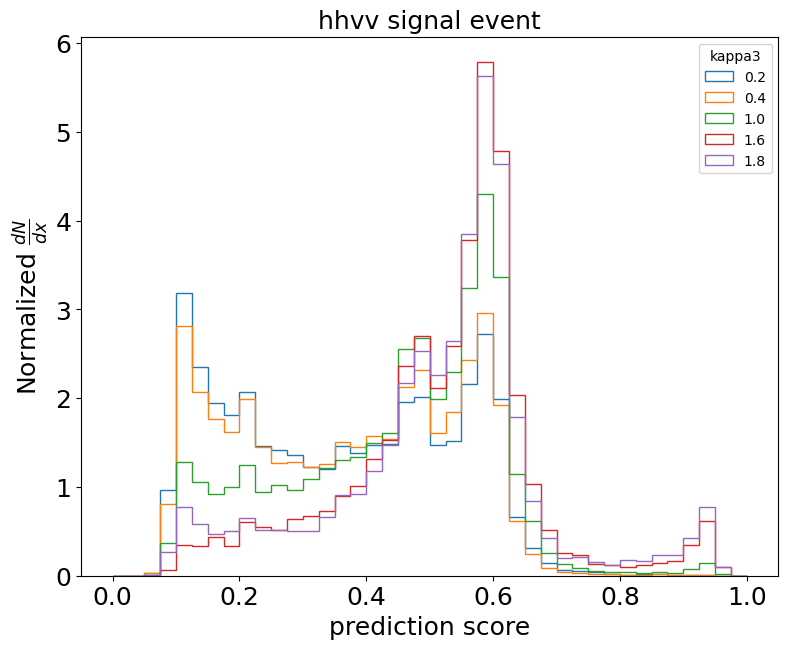

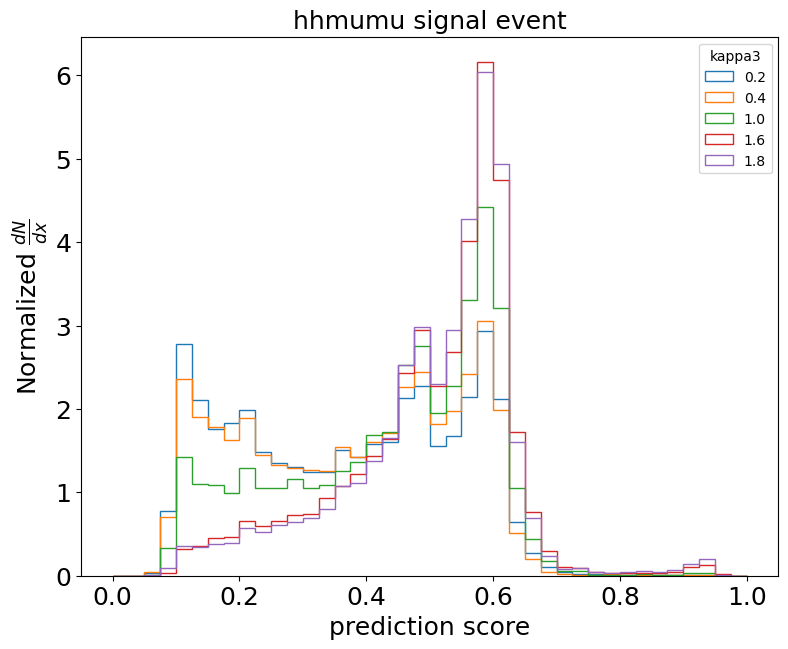

In [10]:
##### plot the prediction histogram #####

plt.figure(1, figsize=(9,7))
bins = np.linspace(0,1,41)
# for kappa3_val in kappa3:
for kappa3_val in [0.2, 0.4, 1.0, 1.6, 1.8]:
    plt.hist(hhvv_prediction[kappa3.index(kappa3_val)][:,1], bins=bins, label=kappa3_val, histtype='step', density=True)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"Normalized $\frac{dN}{dx}$", fontsize=18)
plt.title("hhvv signal event", fontsize=18)
plt.legend(loc='best', title='kappa3')
plt.show()

plt.figure(1, figsize=(9,7))
bins = np.linspace(0,1,41)
# for kappa3_val in kappa3:
for kappa3_val in [0.2, 0.4, 1.0, 1.6, 1.8]:
    plt.hist(hhmumu_prediction[kappa3.index(kappa3_val)][:,1], bins=bins, label=kappa3_val, histtype='step', density=True)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"Normalized $\frac{dN}{dx}$", fontsize=18)
plt.title("hhmumu signal event", fontsize=18)
plt.legend(loc='best', title='kappa3')
plt.show()